# Gene expression violin plots — four genes of interest (Fig 7D)

Violin plots of expression (TPM) for the four genes/paralogs of interest
(**Cct7, Cct4, Cct3, Larp7**) across 29 RNA-seq samples grouped by tissue.

## Inputs (from the new merged annotation)
- `paralog_families_counts.tsv` — featureCounts gene-level counts over the
  paralog GFF (rows = `gene_id`, cols = `SRR*` samples)
- `paralog_families.tsv` — paralog family metadata (`gene_name`, `gene_id`,
  `gene_type`, `length`, ...)

Both are derived from the new merged AGAT annotation
`hifiasm-041425-denovoEnhanced_peaks2utr_sorted.agat.gff3` (gene IDs `ID=gene-...`).


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
# ---------------------------------------------------------------------------
# Load expression data (new merged annotation)
# ---------------------------------------------------------------------------
COUNTS_PATH = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families_counts.tsv"
FAMILIES_PATH = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families.tsv"

# featureCounts gene-level counts (index = Geneid = gene_id `ID`)
counts_df = pd.read_csv(COUNTS_PATH, sep='\t', comment='#', index_col=0)
sample_cols = [c for c in counts_df.columns if c.startswith('SRR')]

# paralog family metadata: family, gene_name, gene_id, gene_type, length, ...
families_df = pd.read_csv(FAMILIES_PATH, sep='\t')
print(f'counts: {counts_df.shape[0]} genes x {len(sample_cols)} samples')
print(f'families: {families_df.shape[0]} rows')


counts: 3272 genes x 29 samples
families: 3272 rows


In [10]:
# ---------------------------------------------------------------------------
# Build long-format plot_df with TPM (gene-level, from featureCounts counts)
# ---------------------------------------------------------------------------
meta = families_df[['gene_id', 'gene_name', 'length']].drop_duplicates().set_index('gene_id')

# Melt counts to long format: gene_id, Sample, count
plot_df = counts_df[sample_cols].reset_index().melt(
    id_vars='Geneid', var_name='Sample', value_name='count')
plot_df = plot_df.rename(columns={'Geneid': 'gene_id'})

# TPM normalization (gene-length corrected, per sample)
plot_df['length'] = plot_df['gene_id'].map(meta['length'])
plot_df['RPK'] = plot_df['count'] / (plot_df['length'] / 1000.0)
plot_df['TPM'] = plot_df['RPK'] / plot_df.groupby('Sample')['RPK'].transform('sum') * 1e6

# Map gene_id -> gene_name (Cct7, Cct7-l1, Cct7-dl1, ...) for filtering/plotting
plot_df['Gene'] = plot_df['gene_id'].map(meta['gene_name'])
plot_df = plot_df.dropna(subset=['Gene'])
plot_df.head()


,gene_id,Sample,count,length,RPK,TPM,Gene
0,gene-Aadac,SRR17216293_Aligned.sortedByCoord.out.bam,14,20944,0.668449,0.585241,Aadac
1,gene-Aadac-l1,SRR17216293_Aligned.sortedByCoord.out.bam,1053,18517,56.866663,49.787950,Aadac-l1
2,gene-Aadac-l2,SRR17216293_Aligned.sortedByCoord.out.bam,854,13583,62.872709,55.046368,Aadac-l2
3,gene-Aadac-l3,SRR17216293_Aligned.sortedByCoord.out.bam,104,12941,8.036473,7.036100,Aadac-l3
4,gene-Aadacl4,SRR17216293_Aligned.sortedByCoord.out.bam,190,24069,7.893971,6.911337,Aadacl4


In [11]:
# ---------------------------------------------------------------------------
# Sample -> tissue + palette (29 SRR samples, 6 tissues)
# ---------------------------------------------------------------------------
sample_to_tissue = {
    'SRR17216293': 'skin', 'SRR17216294': 'brain', 'SRR17216295': 'heart',
    'SRR17216296': 'kidney', 'SRR17216297': 'liver', 'SRR17216298': 'lung',
    'SRR17216299': 'skin', 'SRR17216300': 'brain', 'SRR17216301': 'heart',
    'SRR17216302': 'kidney', 'SRR17216303': 'liver', 'SRR17216304': 'lung',
    'SRR17216305': 'skin', 'SRR17216306': 'brain', 'SRR17216307': 'heart',
    'SRR17216308': 'kidney', 'SRR17216309': 'liver', 'SRR17216310': 'lung',
    'SRR17216311': 'brain', 'SRR17216312': 'heart', 'SRR17216313': 'kidney',
    'SRR17216314': 'kidney', 'SRR17216315': 'lung', 'SRR17216316': 'skin',
    'SRR17216317': 'heart', 'SRR17216318': 'kidney', 'SRR17216319': 'liver',
    'SRR17216320': 'brain', 'SRR17216321': 'lung'
}
tissue_palette = {
    'brain': '#1f77b4', 'heart': '#d62728', 'kidney': '#2ca02c',
    'liver': '#ff7f0e', 'lung': '#9467bd', 'skin': '#e377c2'
}

# featureCounts sample names carry the bam suffix — strip it, then map
plot_df['Sample'] = plot_df['Sample'].str.replace('_Aligned.sortedByCoord.out.bam', '', regex=False)
plot_df['Tissue'] = plot_df['Sample'].map(sample_to_tissue)
plot_df.head()


,gene_id,Sample,count,length,RPK,TPM,Gene,Tissue
0,gene-Aadac,SRR17216293,14,20944,0.668449,0.585241,Aadac,skin
1,gene-Aadac-l1,SRR17216293,1053,18517,56.866663,49.787950,Aadac-l1,skin
2,gene-Aadac-l2,SRR17216293,854,13583,62.872709,55.046368,Aadac-l2,skin
3,gene-Aadac-l3,SRR17216293,104,12941,8.036473,7.036100,Aadac-l3,skin
4,gene-Aadacl4,SRR17216293,190,24069,7.893971,6.911337,Aadacl4,skin


/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_plot_df, x='Gene', y='TPM', ax=ax, palette='pastel',


Paralogs per gene: {'Cct7': 8, 'Cct4': 3, 'Cct3': 4, 'Larp7': 6}


/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_plot_df, x='Gene', y='TPM', ax=ax, palette='pastel',
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_4108925/3637769729.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipyk

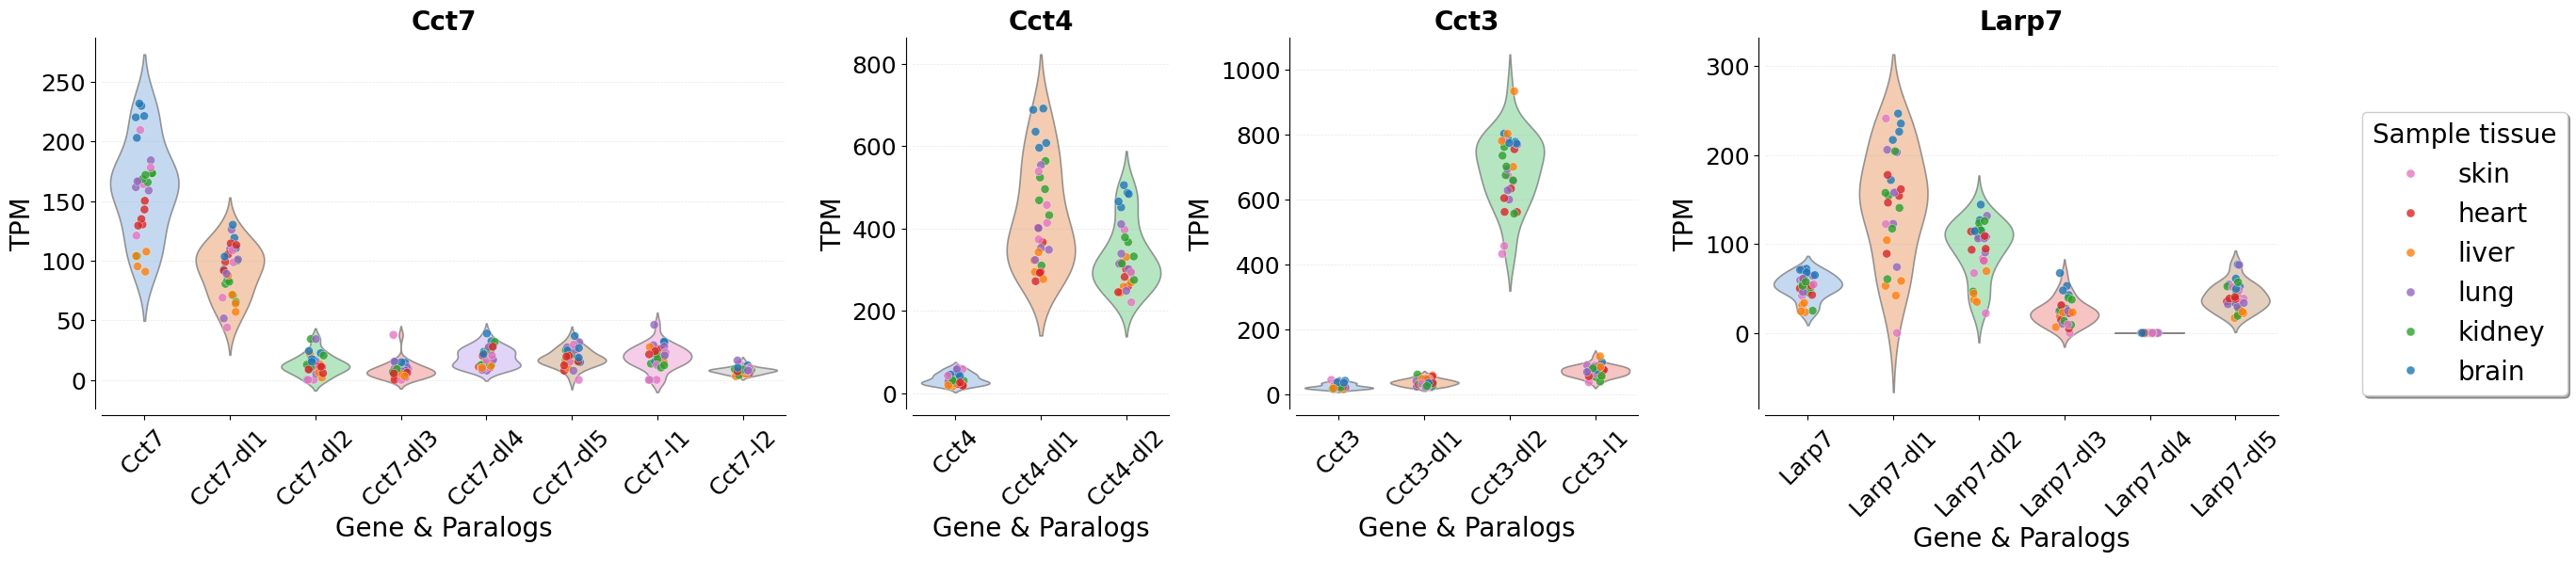

In [12]:
size = 20
# The four genes/paralogs of interest
goi_list = ["Cct7", "Cct4", "Cct3", "Larp7"]

# Count paralogs per gene to set subplot width ratios
width_ratios = []
for goi in goi_list:
    final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
    width_ratios.append(len(final_plot_df['Gene'].unique()))
print(f"Paralogs per gene: {dict(zip(goi_list, width_ratios))}")

fig, axes = plt.subplots(1, len(goi_list), figsize=(24.5, 5.5),
                         gridspec_kw={'width_ratios': width_ratios})

for i, goi in enumerate(goi_list):
    final_plot_df = plot_df[plot_df["Gene"].str.contains(rf"^{goi}(-.*)?$", regex=True)]
    final_plot_df = final_plot_df.sort_values("Gene")
    ax = axes[i]

    sns.violinplot(data=final_plot_df, x='Gene', y='TPM', ax=ax, palette='pastel',
                   inner=None, alpha=0.7, linewidth=1.2)
    sns.stripplot(data=final_plot_df, x='Gene', y='TPM', hue='Tissue', ax=ax,
                  palette=tissue_palette, size=6.5, jitter=True,
                  alpha=0.8, edgecolor='white', linewidth=0.3)

    ax.set_title(f"{goi}", fontsize=size, fontweight="bold")
    ax.set_ylabel('TPM', fontsize=size)
    ax.set_xlabel('Gene & Paralogs', fontsize=size)
    ax.tick_params(axis='x', rotation=45, labelsize=size-2)
    ax.tick_params(axis='y', labelsize=size-2)
    sns.despine(top=True, right=True, offset=5, trim=False, ax=ax)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.get_legend().remove()

# Single shared tissue legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Sample tissue", title_fontsize=size,
           loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1,
           frameon=True, fancybox=True, shadow=True, fontsize=size)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()


In [13]:
# Save figure
fig.savefig("four_genes_expression_violin.png", dpi=300, bbox_inches="tight")
